In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../../../")
from config.label_matchers import matchers

### Load the data:

In [2]:
df = pd.read_csv("./Dataset-safety-bugs.csv")

In [3]:
print("Number of instances:", df.shape[0])

Number of instances: 1916


In [4]:
df.sample(5)

,ID,ISSUE_URL,Sentence,isTitle/Description,IS_OB,IS_EB,IS_S2R,IS_SAFETY_FINAL,RelevantKeyword(s)
955,956,https://github.com/ArduPilot/ardupilot/issues/...,"- when an RTL is triggered, maybe we should ch...",D,YES,YES,NO,YES,return location fence;fence;;
1754,1755,https://github.com/ArduPilot/ardupilot/pull/15473,>This PR (like the previous one) fixes Copter'...,D,NO,NO,NO,YES,disarm;parachute; descent rate;;
678,679,https://github.com/ArduPilot/ardupilot/issues/656,GCS failsafe is disabled by default (because i...,D,YES,NO,NO,NO,;;;
1761,1762,https://github.com/ArduPilot/ardupilot/pull/15473,>@tridge would you be able to re-test with Pla...,D,NaN,NaN,NaN,NO,;;;
1251,1252,https://github.com/ArduPilot/ardupilot/issues/...,"><img width=""436"" alt=""screen shot 2018-03-21 ...",D,NaN,NaN,NaN,NO,;;;


In [5]:
df.rename(columns={"ID": "id", "Sentence": "text", "IS_SAFETY_FINAL": "label"}, inplace=True)

In [6]:
matcher = {v: k for (k, v) in matchers["safety_issue"].items()}
df["label"] = df["label"].replace(matcher).astype(int)

/tmp/ipykernel_371340/2098586601.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"] = df["label"].replace(matcher).astype(int)


### Clean the data:

In [7]:
print("Number of missing texts:", df["text"].isnull().sum())

Number of missing texts: 0


In [8]:
print("Number of missing labels:", df["label"].isnull().sum())

Number of missing labels: 0


In [9]:
print(f"Number of duplicated texts: {df["text"].duplicated().sum()} ({df["text"].duplicated().sum()/df.shape[0]:.2%})")

Number of duplicated texts: 65 (3.39%)


### Analyze distributions:

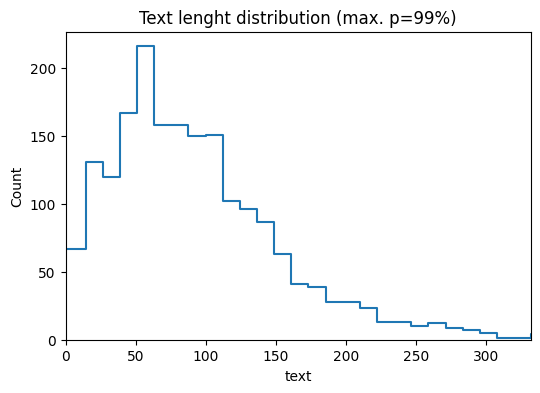

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df["text"].str.len(), element="step", fill=False)
plt.xlim([
    0,
    df["text"].str.len().quantile(.99)
])
plt.title("Text lenght distribution (max. p=99%)")
plt.show()

In [11]:
df["label"].value_counts(dropna=False, normalize=True).round(2)

label
0    0.56
1    0.44
Name: proportion, dtype: float64

### Persist datasets:

In [12]:
df[["id", "text", "label"]].to_parquet("./safety_issue.parquet", index=False)

In [13]:
print("Number of instances in the persisted dataset:", df.shape[0])

Number of instances in the persisted dataset: 1916
